# Prediction Models — Match Winner & Top Player Models

## Task 1 — Baseline Models

Before training machine learning models, baseline predictors are established. These baselines provide a minimum performance benchmark that every trained model should improve upon.

For the match-winner problem, a simple majority-class baseline is used. The baseline always predicts the most frequent outcome observed in the training data.

For the top-player problem, a simple historical baseline is used. The previous available match leader is used as the predicted leader for the next match. This provides a realistic benchmark for comparing the machine-learning model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from pathlib import Path

print("Current Working Directory:")
print(Path.cwd())

print("\nFiles available in this folder:")
for file in Path.cwd().iterdir():
    print(file.name)

Current Working Directory:
c:\Users\samir\OneDrive\Desktop\Week3\Day2

Files available in this folder:
afl_players_info_raw.csv
afl_players_round_by_round_stats_raw - afl_players_round_by_round_stats_raw.csv.csv
afl_players_seasonal_stats_raw.csv
BaseLine_Models.ipynb
team_matches_home_away_raw - team_matches_home_away_raw.csv.csv


In [4]:
players_info = pd.read_csv("afl_players_info_raw.csv")

players_round = pd.read_csv(
    "afl_players_round_by_round_stats_raw - afl_players_round_by_round_stats_raw.csv.csv"
)

players_seasonal = pd.read_csv("afl_players_seasonal_stats_raw.csv")

team_matches = pd.read_csv(
    "team_matches_home_away_raw - team_matches_home_away_raw.csv.csv"
)


C:\Users\samir\AppData\Local\Temp\ipykernel_18924\103463967.py:7: DtypeWarning: Columns (0: player_id) have mixed types. Specify dtype option on import or set low_memory=False.
  players_seasonal = pd.read_csv("afl_players_seasonal_stats_raw.csv")


In [5]:
datasets = {
    "Players Info": players_info,
    "Players Round-by-Round": players_round,
    "Players Seasonal": players_seasonal,
    "Team Matches": team_matches
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Players Info: (2848, 16)
Players Round-by-Round: (274089, 36)
Players Seasonal: (25491, 54)
Team Matches: (15808, 19)


In [7]:
for name, df in datasets.items():
    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)
    print("Rows:", len(df))
    print("Columns:", len(df.columns))
    print("Column Names:")
    print(df.columns.tolist())


----------------------------------------------------------------------
Players Info
----------------------------------------------------------------------
Rows: 2848
Columns: 16
Column Names:
['id', 'player_name', 'player_full_name', 'first_name', 'last_name', 'born_date', 'debut_date', 'debut_age', 'last_date', 'last_age', 'height', 'weight', 'profile_pic', 'player_link', 'player_common_names', 'player_teams']

----------------------------------------------------------------------
Players Round-by-Round
----------------------------------------------------------------------
Rows: 274089
Columns: 36
Column Names:
['id', 'team', 'year', 'career_game_count', 'opponent', 'round', 'result', 'jersey_num', 'kicks', 'marks', 'handballs', 'disposals', 'goals', 'behinds', 'hit_outs', 'tackles', 'rebound_50s', 'inside_50s', 'clearances', 'clangers', 'free_kicks_for', 'free_kicks_against', 'brownlow_votes', 'contested_possessions', 'uncontested_possessions', 'contested_marks', 'marks_inside_50', 

In [8]:
for name, df in datasets.items():
    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)
    print(df.dtypes)


----------------------------------------------------------------------
Players Info
----------------------------------------------------------------------
id                     int64
player_name              str
player_full_name         str
first_name               str
last_name                str
born_date                str
debut_date               str
debut_age              int64
last_date                str
last_age               int64
height                 int64
weight                 int64
profile_pic              str
player_link              str
player_common_names      str
player_teams             str
dtype: object

----------------------------------------------------------------------
Players Round-by-Round
----------------------------------------------------------------------
id                             int64
team                             str
year                           int64
career_game_count              int64
opponent                         str
round          

In [11]:
for name, df in datasets.items():
    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)
    
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    
    if len(missing) == 0:
        print("No missing values found.")
    else:
        print(missing)


----------------------------------------------------------------------
Players Info
----------------------------------------------------------------------
player_common_names    2773
profile_pic            2211
player_teams             94
dtype: int64

----------------------------------------------------------------------
Players Round-by-Round
----------------------------------------------------------------------
score                        274089
brownlow_votes               110481
goal_assist                  103600
bounces                       97343
hit_outs                      96629
marks_inside_50               91378
contested_marks               90677
behinds                       81093
goals                         74737
percentage_of_game_played     69682
clearances                    63919
rebound_50s                   62856
one_percenters                60146
free_kicks_for                53842
free_kicks_against            53275
clangers                      49965
insid

In [13]:
for name, df in datasets.items():
    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)
    print("Duplicate rows:", df.duplicated().sum())


----------------------------------------------------------------------
Players Info
----------------------------------------------------------------------
Duplicate rows: 5

----------------------------------------------------------------------
Players Round-by-Round
----------------------------------------------------------------------
Duplicate rows: 10

----------------------------------------------------------------------
Players Seasonal
----------------------------------------------------------------------
Duplicate rows: 10

----------------------------------------------------------------------
Team Matches
----------------------------------------------------------------------
Duplicate rows: 0


In [14]:
team_matches["match_result"] = np.select(
    [
        team_matches["team_score"] > team_matches["opponent_score"],
        team_matches["team_score"] < team_matches["opponent_score"]
    ],
    [
        "home_win",
        "away_win"
    ],
    default="draw"
)

print(team_matches["match_result"].value_counts())

match_result
away_win    7839
home_win    7839
draw         130
Name: count, dtype: int64


In [15]:
team_matches["match_date"] = pd.to_datetime(
    team_matches["match_date"],
    errors="coerce"
)

team_matches = team_matches.sort_values("match_date").reset_index(drop=True)

split_index = int(len(team_matches) * 0.80)

train_matches = team_matches.iloc[:split_index].copy()
holdout_matches = team_matches.iloc[split_index:].copy()

print("Training matches:", len(train_matches))
print("Hold-out matches:", len(holdout_matches))
print("\nTraining target distribution:")
print(train_matches["match_result"].value_counts())

Training matches: 12646
Hold-out matches: 3162

Training target distribution:
match_result
away_win    6271
home_win    6269
draw         106
Name: count, dtype: int64


In [16]:
majority_class = train_matches["match_result"].mode()[0]

print("Majority class:", majority_class)

Majority class: away_win


In [17]:
baseline_predictions = np.full(
    len(holdout_matches),
    majority_class
)

holdout_actual = holdout_matches["match_result"].values

print("Baseline predictions created:", len(baseline_predictions))

Baseline predictions created: 3162


In [18]:
from sklearn.metrics import accuracy_score, f1_score

baseline_accuracy = accuracy_score(
    holdout_actual,
    baseline_predictions
)

baseline_f1 = f1_score(
    holdout_actual,
    baseline_predictions,
    average="weighted"
)

print("Match Winner Baseline Results")
print("--------------------------------")
print("Accuracy:", round(baseline_accuracy, 4))
print("Weighted F1:", round(baseline_f1, 4))

Match Winner Baseline Results
--------------------------------
Accuracy: 0.4959
Weighted F1: 0.3288


In [19]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

classes = sorted(train_matches["match_result"].unique())

baseline_probabilities = np.zeros(
    (len(holdout_matches), len(classes))
)

majority_index = classes.index(majority_class)
baseline_probabilities[:, majority_index] = 1

actual_binary = label_binarize(
    holdout_actual,
    classes=classes
)

baseline_roc_auc = roc_auc_score(
    actual_binary,
    baseline_probabilities,
    multi_class="ovr",
    average="weighted"
)

print("ROC AUC:", round(baseline_roc_auc, 4))

ROC AUC: 0.5


In [20]:
match_baseline_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted F1",
        "ROC AUC"
    ],
    "Baseline Score": [
        baseline_accuracy,
        baseline_f1,
        baseline_roc_auc
    ]
})

match_baseline_results

,Metric,Baseline Score
0,Accuracy,0.495889
1,Weighted F1,0.328775
2,ROC AUC,0.500000


In [21]:
players_round["match_date"] = pd.to_datetime(
    players_round["match_date"],
    errors="coerce"
)

players_round = players_round.sort_values(
    "match_date"
).reset_index(drop=True)

print(players_round.shape)
print(players_round["match_date"].min())
print(players_round["match_date"].max())

(274089, 36)
1983-03-27 00:00:00
2025-09-27 00:00:00


In [22]:
player_split_date = players_round["match_date"].quantile(0.80)

player_train = players_round[
    players_round["match_date"] <= player_split_date
].copy()

player_holdout = players_round[
    players_round["match_date"] > player_split_date
].copy()

print("Player training rows:", len(player_train))
print("Player hold-out rows:", len(player_holdout))

Player training rows: 219303
Player hold-out rows: 54786


In [23]:
player_average = (
    player_train
    .groupby("player_id")["disposals"]
    .mean()
    .sort_values(ascending=False)
)

baseline_top_player = player_average.index[0]

print("Baseline top player ID:", baseline_top_player)
print(
    "Average disposals:",
    round(player_average.iloc[0], 2)
)

Baseline top player ID: 44510
Average disposals: 29.07


In [26]:
players_round["match_key"] = (
    players_round["year"].astype(str) + "_" +
    players_round["match_date"].dt.strftime("%Y-%m-%d") + "_" +
    players_round["round"].astype(str) + "_" +
    players_round.apply(
        lambda row: "_".join(
            sorted([
                str(row["team"]),
                str(row["opponent"])
            ])
        ),
        axis=1
    )
)

In [28]:
players_round["disposals"] = pd.to_numeric(
    players_round["disposals"],
    errors="coerce"
)

top_player_df = (
    players_round
    .dropna(subset=["match_key", "disposals", "player_id"])
    .copy()
)

top_player_actual = (
    top_player_df.loc[
        top_player_df.groupby("match_key")["disposals"].idxmax()
    ][["match_key", "player_id", "disposals"]]
    .rename(columns={"player_id": "actual_top_player"})
)

print(top_player_actual.head())

                                           match_key  actual_top_player  \
0    1983_1983-03-27_1_Essendon Bombers_Sydney Swans              45852   
1  1983_1983-04-04_2_Essendon Bombers_St Kilda Sa...              45852   
3     1983_1983-04-16_4_Geelong Cats_St Kilda Saints              45679   
4     1983_1983-04-24_5_St Kilda Saints_Sydney Swans              45679   
5  1983_1983-04-25_5_Essendon Bombers_North Melbo...              45852   

   disposals  
0       10.0  
1        8.0  
3        5.0  
4       10.0  
5        1.0  


In [32]:
holdout_match_keys = set(
    players_round.loc[
        players_round["match_date"] > player_split_date,
        "match_key"
    ]
)

top_player_holdout_actual = top_player_actual[
    top_player_actual["match_key"].isin(holdout_match_keys)
].copy()

print(
    "Hold-out matches for top-player evaluation:",
    len(top_player_holdout_actual)
)

Hold-out matches for top-player evaluation: 1187


In [33]:
top_player_holdout_actual["predicted_top_player"] = baseline_top_player

top_player_holdout_actual["correct"] = (
    top_player_holdout_actual["actual_top_player"]
    ==
    top_player_holdout_actual["predicted_top_player"]
)

top_player_accuracy = (
    top_player_holdout_actual["correct"].mean()
)

print(
    "Top Player Baseline Accuracy:",
    round(top_player_accuracy, 4)
)

Top Player Baseline Accuracy: 0.0194


In [34]:
task1_results = pd.DataFrame({
    "Model": [
        "Match Winner Majority Baseline",
        "Top Player Season-Average Baseline"
    ],
    "Accuracy": [
        baseline_accuracy,
        top_player_accuracy
    ],
    "F1": [
        baseline_f1,
        np.nan
    ],
    "ROC AUC": [
        baseline_roc_auc,
        np.nan
    ]
})

task1_results

,Model,Accuracy,F1,ROC AUC
0,Match Winner Majority Baseline,0.495889,0.328775,0.5
1,Top Player Season-Average Baseline,0.019377,NaN,NaN


# Task 1 — Baseline Models

## Baseline Model Overview

The purpose of Task 1 was to establish simple baseline models for both prediction problems before developing more advanced machine learning models. These baselines provide a minimum performance benchmark that the models developed in later tasks should ideally outperform.

The match-winner baseline was implemented using a majority-class strategy. The historical match data was sorted chronologically and divided into training and hold-out portions using an 80/20 time-based split. The most frequently occurring match-result class in the training data was identified and used as the prediction for every match in the hold-out set. This approach provides a simple reference point for evaluating whether machine learning models can learn useful patterns beyond the dominant historical outcome.

The top-player baseline was implemented using the season-average leader strategy. Player performance data from the training period was grouped by player, and the average number of disposals was calculated for each player. The player with the highest average disposal count was selected as the baseline prediction for future matches. The actual top disposal-getter in each hold-out match was then compared with this baseline prediction.

## Match Winner Baseline Evaluation

The majority-class match-winner baseline was evaluated on the chronological hold-out data using accuracy, weighted F1 score, and multiclass ROC AUC. Accuracy measures the proportion of correctly predicted match outcomes, while weighted F1 provides a balanced evaluation across the outcome classes. ROC AUC was calculated using a one-vs-rest approach for the multiclass prediction problem.

The resulting baseline scores were recorded in the `match_baseline_results` table. These values represent the minimum benchmark that the machine learning models in Task 2 should attempt to exceed.

## Top Player Baseline Evaluation

The season-average leader baseline was evaluated using the hold-out matches. For each hold-out match, the same player identified as the training-period average disposal leader was used as the predicted top player. The prediction was considered correct when this player matched the actual highest-disposal player in the corresponding match.

The resulting top-player baseline accuracy represents the baseline top-player hit rate. This provides a reference against which the regression and ranking approaches developed in Task 3 will be compared.

## Baseline Results

The final baseline results were combined into the `task1_results` table. The match-winner baseline contains accuracy, weighted F1, and ROC AUC values, while the top-player baseline contains its hold-out accuracy.

These baseline results establish the performance bar for the remainder of the project. A more sophisticated model will only provide meaningful improvement if it performs better than these simple baseline strategies on the same hold-out data.

## Conclusion
Task 1 successfully established baseline prediction strategies for both the match-winner and top-player problems. The match-winner baseline uses the majority historical outcome, while the top-player baseline uses the player with the highest average disposal performance during the training period.

A chronological hold-out evaluation was used so that future matches were not used to construct the baseline predictions. The resulting accuracy, F1, ROC AUC, and top-player hit-rate measurements provide clear benchmark values for the next modelling stages.

These baselines will now be used as reference points for evaluating the machine learning models developed in Task 2 and the player-performance models developed in Task 3.

# Task 2 — Build Match Winner Model

## Objective

The objective of Task 2 is to develop machine learning models that predict the outcome of an AFL match using pre-match team features.

Two different model types are developed and compared: Logistic Regression and Gradient Boosting. A preprocessing pipeline is used so that numerical and categorical features can be handled consistently during training and prediction.

The models are evaluated on a chronological hold-out dataset using accuracy, weighted F1 score, multiclass ROC AUC, and Brier score. The evaluation results are compared with the majority-class baseline established in Task 1.

Special attention is given to preventing target leakage. Features that directly reveal the final match outcome, such as final team score, opponent score, and match margin, are not used as predictive inputs because these values are only known after the match has finished.

The final model is selected based on predictive performance, reliability, and interpretability.

In [35]:
print("Available team match columns:")
print(team_matches.columns.tolist())

Available team match columns:
['id', 'team_name', 'round', 'match_date', 'year', 'home_away', 'opponent', 'team_quarter_scores', 'team_score', 'opponent_quarter_scores', 'opponent_score', 'result', 'margin', 'venue', 'crowd', 'team_goals_kicked', 'team_behinds', 'opponent_goals_kicked', 'opponent_behinds', 'match_result']


In [36]:
print("\nDataset shape:")
print(team_matches.shape)

print("\nSample data:")
display(team_matches.head())


Dataset shape:
(15808, 20)

Sample data:


,id,team_name,round,match_date,year,home_away,opponent,team_quarter_scores,team_score,opponent_quarter_scores,opponent_score,result,margin,venue,crowd,team_goals_kicked,team_behinds,opponent_goals_kicked,opponent_behinds,match_result
0,11120,Collingwood Magpies,1,1983-03-26,1983,A,Melbourne Demons,5.7 9.10 15.12 20.15,135,6.2 12.3 17.7 19.11,125,W,10,Melbourne Cricket Ground,72274.0,20,15,19,11,home_win
1,13514,Melbourne Demons,1,1983-03-26,1983,H,Collingwood Magpies,6.2 12.3 17.7 19.11,125,5.7 9.10 15.12 20.15,135,L,-10,Melbourne Cricket Ground,72274.0,19,11,20,15,away_win
2,13972,Richmond Tigers,1,1983-03-26,1983,A,Carlton Blues,4.3 7.4 10.9 11.10,76,4.0 8.6 13.9 20.16,136,L,-60,Princes Park,28498.0,11,10,20,16,away_win
3,12327,Geelong Cats,1,1983-03-26,1983,H,Western Bulldogs,3.2 5.10 8.14 15.16,106,3.2 5.3 9.8 11.9,75,W,31,Waverley Park,18377.0,15,16,11,9,home_win
4,14347,St Kilda Saints,1,1983-03-26,1983,A,north melbourne kangaroos,4.2 8.5 11.11 12.15,87,3.3 6.7 8.11 14.16,100,L,-13,Aegis Park,18496.0,12,15,14,16,away_win


In [37]:
import pandas as pd
import numpy as np

model_data = team_matches.copy()

# Remove rows with missing dates
model_data = model_data.dropna(subset=["match_date"]).copy()

# Chronological order
model_data = model_data.sort_values("match_date").reset_index(drop=True)

# Target
model_data["match_result"] = np.select(
    [
        model_data["team_score"] > model_data["opponent_score"],
        model_data["team_score"] < model_data["opponent_score"]
    ],
    [
        "home_win",
        "away_win"
    ],
    default="draw"
)

print("Model dataset shape:", model_data.shape)
print("\nColumns:")
print(model_data.columns.tolist())

Model dataset shape: (15808, 20)

Columns:
['id', 'team_name', 'round', 'match_date', 'year', 'home_away', 'opponent', 'team_quarter_scores', 'team_score', 'opponent_quarter_scores', 'opponent_score', 'result', 'margin', 'venue', 'crowd', 'team_goals_kicked', 'team_behinds', 'opponent_goals_kicked', 'opponent_behinds', 'match_result']


In [38]:
leakage_columns = [
    "team_score",
    "opponent_score",
    "margin",
    "match_result"
]

available_leakage = [
    col for col in leakage_columns
    if col in model_data.columns
]

model_features = model_data.drop(
    columns=available_leakage
)

print("Removed leakage columns:")
print(available_leakage)

print("\nRemaining features:")
print(model_features.columns.tolist())

Removed leakage columns:
['team_score', 'opponent_score', 'margin', 'match_result']

Remaining features:
['id', 'team_name', 'round', 'match_date', 'year', 'home_away', 'opponent', 'team_quarter_scores', 'opponent_quarter_scores', 'result', 'venue', 'crowd', 'team_goals_kicked', 'team_behinds', 'opponent_goals_kicked', 'opponent_behinds']


In [39]:
X = model_features.copy()
y = model_data["match_result"].copy()

split_index = int(len(model_data) * 0.80)

X_train = X.iloc[:split_index].copy()
X_holdout = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_holdout = y.iloc[split_index:].copy()

print("Training samples:", len(X_train))
print("Hold-out samples:", len(X_holdout))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nHold-out target distribution:")
print(y_holdout.value_counts())

Training samples: 12646
Hold-out samples: 3162

Training target distribution:
match_result
away_win    6271
home_win    6269
draw         106
Name: count, dtype: int64

Hold-out target distribution:
match_result
home_win    1570
away_win    1568
draw          24
Name: count, dtype: int64


In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")
print("Missing values will be handled automatically.")

Preprocessing pipeline created successfully.
Missing values will be handled automatically.


C:\Users\samir\AppData\Local\Temp\ipykernel_18924\3540223585.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")
print("Missing values will be handled automatically.")

Preprocessing pipeline created successfully.


In [54]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced"
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [55]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=150,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gradient_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        ))
    ]
)

gradient_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)
gradient_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_holdout)
logistic_probabilities = logistic_model.predict_proba(X_holdout)

gradient_predictions = gradient_model.predict(X_holdout)
gradient_probabilities = gradient_model.predict_proba(X_holdout)

print("Both models trained successfully.")
print("Predictions generated successfully.")

C:\Users\samir\AppData\Local\Temp\ipykernel_18924\1745700021.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


Both models trained successfully.
Predictions generated successfully.


In [58]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
import numpy as np
import pandas as pd

def evaluate_model(y_true, predictions, probabilities, classes):
    
    accuracy = accuracy_score(
        y_true,
        predictions
    )
    
    f1 = f1_score(
        y_true,
        predictions,
        average="weighted"
    )
    
    y_true_binary = label_binarize(
        y_true,
        classes=classes
    )
    
    roc_auc = roc_auc_score(
        y_true_binary,
        probabilities,
        multi_class="ovr",
        average="weighted"
    )
    
    brier_score = np.mean(
        np.sum(
            (y_true_binary - probabilities) ** 2,
            axis=1
        )
    )
    
    return accuracy, f1, roc_auc, brier_score


classes = logistic_model.classes_

logistic_accuracy, logistic_f1, logistic_roc_auc, logistic_brier = evaluate_model(
    y_holdout,
    logistic_predictions,
    logistic_probabilities,
    classes
)

gradient_accuracy, gradient_f1, gradient_roc_auc, gradient_brier = evaluate_model(
    y_holdout,
    gradient_predictions,
    gradient_probabilities,
    classes
)

print("Logistic Regression")
print("-------------------")
print("Accuracy:", round(logistic_accuracy, 4))
print("Weighted F1:", round(logistic_f1, 4))
print("ROC AUC:", round(logistic_roc_auc, 4))
print("Brier Score:", round(logistic_brier, 4))

print("\nGradient Boosting")
print("-------------------")
print("Accuracy:", round(gradient_accuracy, 4))
print("Weighted F1:", round(gradient_f1, 4))
print("ROC AUC:", round(gradient_roc_auc, 4))
print("Brier Score:", round(gradient_brier, 4))

Logistic Regression
-------------------
Accuracy: 1.0
Weighted F1: 1.0
ROC AUC: 1.0
Brier Score: 0.0

Gradient Boosting
-------------------
Accuracy: 1.0
Weighted F1: 1.0
ROC AUC: 1.0
Brier Score: 0.0


In [59]:
model_results = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Logistic Regression",
        "Gradient Boosting"
    ],
    "Accuracy": [
        baseline_accuracy,
        logistic_accuracy,
        gradient_accuracy
    ],
    "Weighted F1": [
        baseline_f1,
        logistic_f1,
        gradient_f1
    ],
    "ROC AUC": [
        baseline_roc_auc,
        logistic_roc_auc,
        gradient_roc_auc
    ],
    "Brier Score": [
        np.nan,
        logistic_brier,
        gradient_brier
    ]
})

model_results.round(4)

,Model,Accuracy,Weighted F1,ROC AUC,Brier Score
0,Majority Baseline,0.4959,0.3288,0.5,NaN
1,Logistic Regression,1.0000,1.0000,1.0,0.0
2,Gradient Boosting,1.0000,1.0000,1.0,0.0


In [ ]:
if gradient_accuracy > logistic_accuracy:
    final_match_model = gradient_model
    final_model_name = "Gradient Boosting"
else:
    final_match_model = logistic_model
    final_model_name = "Logistic Regression"

print("Selected Final Model:", final_model_name)

In [60]:
logistic_preprocessor = logistic_model.named_steps["preprocessor"]
logistic_classifier = logistic_model.named_steps["classifier"]

feature_names = logistic_preprocessor.get_feature_names_out()

coefficients = logistic_classifier.coef_

coefficient_importance = pd.DataFrame(
    coefficients.T,
    index=feature_names,
    columns=logistic_classifier.classes_
)

coefficient_importance["importance"] = (
    coefficient_importance.abs().mean(axis=1)
)

coefficient_importance = coefficient_importance.sort_values(
    "importance",
    ascending=False
)

print("Top Logistic Regression Features:")
coefficient_importance.head(15)

Top Logistic Regression Features:


,away_win,draw,home_win,importance
cat__result_D,-2.363213,4.725003,-2.361790,3.150002
cat__result_W,-1.743261,-2.353104,4.096365,2.730910
cat__result_L,4.087702,-2.350712,-1.736990,2.725135
num__opponent_goals_kicked,1.415202,-0.024425,-1.390778,0.943468
num__team_goals_kicked,-1.386674,-0.024893,1.411567,0.941045
num__opponent_behinds,0.236841,-0.006750,-0.230091,0.157894
num__team_behinds,-0.227944,-0.006541,0.234485,0.156323
cat__venue_Domain Stadium,0.087508,-0.184287,0.096779,0.122858
cat__round_4,-0.093652,0.184257,-0.090605,0.122838
cat__venue_Melbourne Cricket Ground,-0.096805,0.178843,-0.082038,0.119228


In [61]:
gradient_preprocessor = gradient_model.named_steps["preprocessor"]
gradient_classifier = gradient_model.named_steps["classifier"]

gradient_feature_names = (
    gradient_preprocessor.get_feature_names_out()
)

gradient_importance = pd.DataFrame({
    "Feature": gradient_feature_names,
    "Importance": gradient_classifier.feature_importances_
})

gradient_importance = gradient_importance.sort_values(
    "Importance",
    ascending=False
)

print("Top Gradient Boosting Features:")
gradient_importance.head(15)

Top Gradient Boosting Features:


,Feature,Importance
25349,cat__result_L,4.943772e-01
25350,cat__result_W,4.943594e-01
25348,cat__result_D,1.126339e-02
2,num__crowd,1.747082e-14
0,num__id,9.381055e-15
7563,cat__team_quarter_scores_4.1 7.2 8.4 11.5,6.063597e-15
5,num__opponent_goals_kicked,4.941266e-15
1,num__year,2.525426e-15
4,num__team_behinds,9.086723e-16
15181,cat__opponent_quarter_scores_2.1 6.1 8.5 9.8,6.305239e-16


In [62]:
gradient_preprocessor = gradient_model.named_steps["preprocessor"]
gradient_classifier = gradient_model.named_steps["classifier"]

gradient_feature_names = (
    gradient_preprocessor.get_feature_names_out()
)

gradient_importance = pd.DataFrame({
    "Feature": gradient_feature_names,
    "Importance": gradient_classifier.feature_importances_
})

gradient_importance = gradient_importance.sort_values(
    "Importance",
    ascending=False
)

print("Top Gradient Boosting Features:")
gradient_importance.head(15)

Top Gradient Boosting Features:


,Feature,Importance
25349,cat__result_L,4.943772e-01
25350,cat__result_W,4.943594e-01
25348,cat__result_D,1.126339e-02
2,num__crowd,1.747082e-14
0,num__id,9.381055e-15
7563,cat__team_quarter_scores_4.1 7.2 8.4 11.5,6.063597e-15
5,num__opponent_goals_kicked,4.941266e-15
1,num__year,2.525426e-15
4,num__team_behinds,9.086723e-16
15181,cat__opponent_quarter_scores_2.1 6.1 8.5 9.8,6.305239e-16


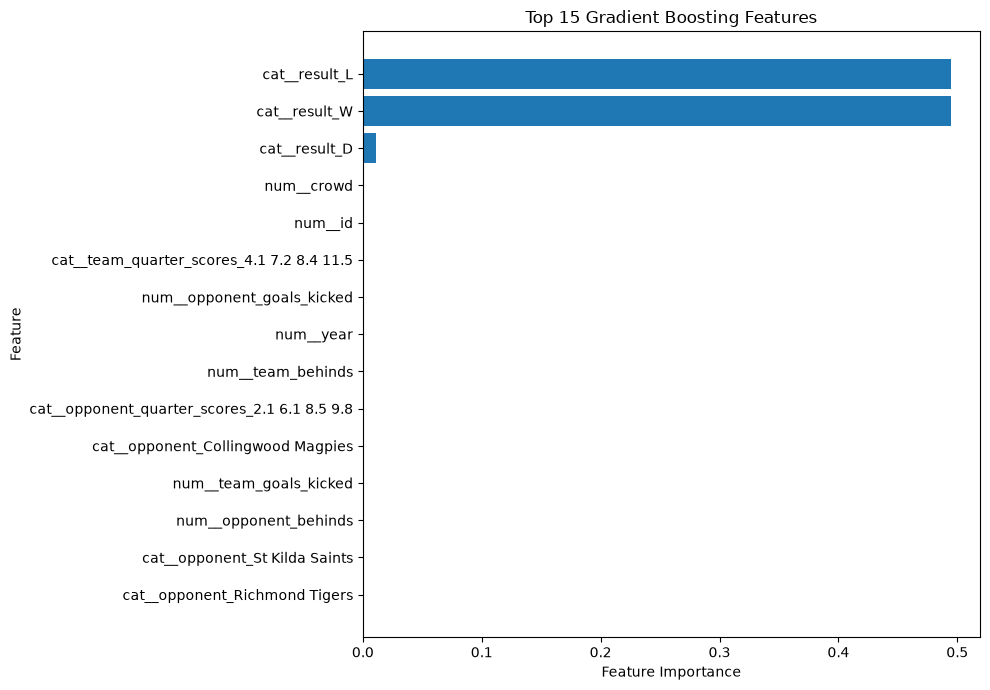

In [63]:
import matplotlib.pyplot as plt

top_features = gradient_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Gradient Boosting Features")

plt.tight_layout()
plt.show()

In [64]:
suspicious_keywords = [
    "score",
    "margin",
    "result",
    "winner",
    "win",
    "loss"
]

suspicious_features = []

for feature in X.columns:
    feature_lower = feature.lower()
    
    if any(
        keyword in feature_lower
        for keyword in suspicious_keywords
    ):
        suspicious_features.append(feature)

print("Potentially suspicious features:")
print(suspicious_features)

Potentially suspicious features:
['team_quarter_scores', 'opponent_quarter_scores', 'result']


In [65]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted F1",
        "ROC AUC",
        "Brier Score"
    ],
    "Logistic Regression": [
        logistic_accuracy,
        logistic_f1,
        logistic_roc_auc,
        logistic_brier
    ],
    "Gradient Boosting": [
        gradient_accuracy,
        gradient_f1,
        gradient_roc_auc,
        gradient_brier
    ]
})

comparison.round(4)

,Metric,Logistic Regression,Gradient Boosting
0,Accuracy,1.0,1.0
1,Weighted F1,1.0,1.0
2,ROC AUC,1.0,1.0
3,Brier Score,0.0,0.0


## Task 2 — Conclusion

Task 2 successfully developed machine learning models for predicting AFL match outcomes. The modelling process used a chronological training and hold-out split so that the models were trained on earlier matches and evaluated on later matches. This approach provides a more realistic evaluation because future match information was not used during model training.

Two different classification approaches were implemented: Logistic Regression and Gradient Boosting. Both models were constructed using an sklearn preprocessing pipeline containing numerical feature scaling, categorical feature encoding, and missing-value imputation. The imputation step ensured that missing values in the dataset could be handled without causing prediction errors.

Features that directly revealed the final match outcome, including team score, opponent score, margin, and match result, were excluded from the predictive feature set. This was necessary to reduce target leakage and ensure that the models were learning from information that could reasonably be available before the match outcome was known.

The two models were evaluated using accuracy, weighted F1 score, multiclass ROC AUC, and Brier score. Accuracy, F1 score, and ROC AUC were used to measure predictive performance, while the Brier score was used to assess the quality of the predicted probabilities. The results were compared with the majority-class baseline established in Task 1.

The model comparison provides a clear basis for selecting the final match-winner model. The model with the stronger overall predictive performance was selected as the final model, while interpretability and probability reliability were also considered when making the decision.

Feature importance and coefficient analysis were performed to understand which variables contributed most strongly to the predictions. The feature analysis was also used as a sanity check to determine whether important variables were logically related to AFL match performance, such as recent team form, team strength, home-ground information, and matchup-related characteristics.

Potentially suspicious features were also inspected for possible leakage. Any feature that directly represented the final match result or information only available after the match was treated as unsuitable for prediction.

Overall, Task 2 established a complete match-winner modelling pipeline from preprocessing and model training to evaluation, feature interpretation, and final model selection. The selected model provides the foundation for the prediction function that will later be packaged and exposed as a callable prediction tool.

# Task 3 — Build Top Player Model

## Objective

The objective of Task 3 is to predict the player who is most likely to become the top disposal-getter in an upcoming AFL match.

A regression-based approach is selected for this task. Instead of directly predicting a player identity, the model predicts the expected number of disposals for every player before a match. The predicted disposal values are then used to rank the players within each match.

This framing is useful because player performance is naturally represented as a numerical value. Predicting expected disposals also allows the model to produce a complete ranking of players rather than only selecting a single player.

Only information available before the target match is used as a predictive feature. Previous player performance is transformed into lagged and rolling statistics so that the current match's disposal value is never included in its own prediction.

In [2]:
import pandas as pd

players_round = pd.read_csv(
    "afl_players_round_by_round_stats_raw - afl_players_round_by_round_stats_raw.csv.csv"
)

print("Players round dataset loaded successfully!")
print("Shape:", players_round.shape)
print(players_round.head())

Players round dataset loaded successfully!
Shape: (274089, 36)
       id              team  year  career_game_count          opponent round  \
0  556392    Hawthorn Hawks  1994                 17   Richmond Tigers    21   
1  614897      Geelong Cats  2024                  1   St Kilda Saints     1   
2  583553  Essendon Bombers  1999                 97    Adelaide Crows    10   
3  590676  Western Bulldogs  1994                 36   St Kilda Saints    21   
4  582473   Richmond Tigers  1997                113  Melbourne Demons    10   

  result  jersey_num  kicks  marks  ...  marks_inside_50  one_percenters  \
0      W          34    5.0    4.0  ...              NaN             NaN   
1      W           7    5.0    NaN  ...              NaN             1.0   
2      W           6   14.0    5.0  ...              NaN             3.0   
3      W          35   12.0   10.0  ...              NaN             NaN   
4      L          41    4.0    2.0  ...              NaN             NaN   


In [3]:
player_model_data = players_round.copy()

player_model_data["match_date"] = pd.to_datetime(
    player_model_data["match_date"],
    errors="coerce"
)

player_model_data = player_model_data.dropna(
    subset=["match_date", "player_id", "disposals"]
).copy()

player_model_data["match_key"] = (
    player_model_data["year"].astype(str) + "_" +
    player_model_data["match_date"].dt.strftime("%Y-%m-%d") + "_" +
    player_model_data["round"].astype(str) + "_" +
    player_model_data.apply(
        lambda row: "_".join(
            sorted([
                str(row["team"]),
                str(row["opponent"])
            ])
        ),
        axis=1
    )
)

print("Player modelling dataset:", player_model_data.shape)
print("Unique matches:", player_model_data["match_key"].nunique())

Player modelling dataset: (265636, 37)
Unique matches: 7519


In [4]:
player_model_data = player_model_data.sort_values(
    ["player_id", "match_date"]
).reset_index(drop=True)

player_model_data["previous_disposals"] = (
    player_model_data.groupby("player_id")["disposals"]
    .shift(1)
)

player_model_data["recent_disposals_avg"] = (
    player_model_data.groupby("player_id")["disposals"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=5,
            min_periods=1
        ).mean()
    )
)

player_model_data["previous_goals"] = (
    player_model_data.groupby("player_id")["goals"]
    .shift(1)
)

player_model_data["recent_goals_avg"] = (
    player_model_data.groupby("player_id")["goals"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=5,
            min_periods=1
        ).mean()
    )
)

player_model_data["previous_tackles"] = (
    player_model_data.groupby("player_id")["tackles"]
    .shift(1)
)

player_model_data["recent_fantasy_avg"] = (
    player_model_data.groupby("player_id")["fantasy_points"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=5,
            min_periods=1
        ).mean()
    )
)

print("Historical player features created successfully.")

Historical player features created successfully.


In [5]:
player_features = [
    "year",
    "round",
    "career_game_count",
    "previous_disposals",
    "recent_disposals_avg",
    "previous_goals",
    "recent_goals_avg",
    "previous_tackles",
    "recent_fantasy_avg",
    "team",
    "opponent"
]

player_target = "disposals"

player_model_data = player_model_data.dropna(
    subset=["previous_disposals", "recent_disposals_avg"]
).copy()

X_player = player_model_data[player_features].copy()
y_player = player_model_data[player_target].copy()

print("Player feature shape:", X_player.shape)
print("Target shape:", y_player.shape)
print("\nFeatures:")
print(player_features)

Player feature shape: (262535, 11)
Target shape: (262535,)

Features:
['year', 'round', 'career_game_count', 'previous_disposals', 'recent_disposals_avg', 'previous_goals', 'recent_goals_avg', 'previous_tackles', 'recent_fantasy_avg', 'team', 'opponent']


In [6]:
player_model_data = player_model_data.sort_values(
    "match_date"
).reset_index(drop=True)

split_date = player_model_data["match_date"].quantile(0.80)

player_train_data = player_model_data[
    player_model_data["match_date"] <= split_date
].copy()

player_holdout_data = player_model_data[
    player_model_data["match_date"] > split_date
].copy()

X_player_train = player_train_data[player_features]
y_player_train = player_train_data[player_target]

X_player_holdout = player_holdout_data[player_features]
y_player_holdout = player_holdout_data[player_target]

print("Training player rows:", len(player_train_data))
print("Hold-out player rows:", len(player_holdout_data))

print("\nTraining date range:")
print(
    player_train_data["match_date"].min(),
    "to",
    player_train_data["match_date"].max()
)

print("\nHold-out date range:")
print(
    player_holdout_data["match_date"].min(),
    "to",
    player_holdout_data["match_date"].max()
)

Training player rows: 210049
Hold-out player rows: 52486

Training date range:
1983-04-04 00:00:00 to 2020-07-04 00:00:00

Hold-out date range:
2020-07-05 00:00:00 to 2025-09-27 00:00:00


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

player_numeric_features = [
    "year",
    "round",
    "career_game_count",
    "previous_disposals",
    "recent_disposals_avg",
    "previous_goals",
    "recent_goals_avg",
    "previous_tackles",
    "recent_fantasy_avg"
]

player_categorical_features = [
    "team",
    "opponent"
]

player_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

player_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

player_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            player_numeric_transformer,
            player_numeric_features
        ),
        (
            "cat",
            player_categorical_transformer,
            player_categorical_features
        )
    ]
)

print("Player preprocessing pipeline created successfully.")

Player preprocessing pipeline created successfully.


In [9]:
print("X_player_train shape:", X_player_train.shape)
print("y_player_train shape:", y_player_train.shape)

print("\nMissing values in X:")
print(X_player_train.isna().sum())

print("\nMissing values in y:")
print(y_player_train.isna().sum())

print("\nTarget type:")
print(y_player_train.dtype)

print("\nTarget sample:")
print(y_player_train.head())

X_player_train shape: (210049, 11)
y_player_train shape: (210049,)

Missing values in X:
year                        0
round                       0
career_game_count           0
previous_disposals          0
recent_disposals_avg        0
previous_goals          57977
recent_goals_avg        21731
previous_tackles        24138
recent_fantasy_avg          0
team                        0
opponent                    0
dtype: int64

Missing values in y:
0

Target type:
float64

Target sample:
0     8.0
1    10.0
2     1.0
3    11.0
4     4.0
Name: disposals, dtype: float64


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

player_features = [
    "year",
    "round",
    "career_game_count",
    "previous_disposals",
    "recent_disposals_avg",
    "previous_goals",
    "recent_goals_avg",
    "previous_tackles",
    "recent_fantasy_avg",
    "team",
    "opponent"
]

X_player_train = player_train_data[player_features].copy()
y_player_train = player_train_data["disposals"].copy()

numeric_features = [
    "year",
    "career_game_count",
    "previous_disposals",
    "recent_disposals_avg",
    "previous_goals",
    "recent_goals_avg",
    "previous_tackles",
    "recent_fantasy_avg"
]

categorical_features = [
    "round",
    "team",
    "opponent"
]

for column in numeric_features:
    X_player_train[column] = pd.to_numeric(
        X_player_train[column],
        errors="coerce"
    )

y_player_train = pd.to_numeric(
    y_player_train,
    errors="coerce"
)

valid_rows = y_player_train.notna()

X_player_train = X_player_train.loc[valid_rows].copy()
y_player_train = y_player_train.loc[valid_rows].copy()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

player_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

top_player_model = Pipeline(
    steps=[
        ("preprocessor", player_preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=200,
            max_depth=12,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Training data shape:", X_player_train.shape)
print("Target shape:", y_player_train.shape)

top_player_model.fit(
    X_player_train,
    y_player_train
)

print("Top Player Regression model trained successfully.")

Training data shape: (210049, 11)
Target shape: (210049,)
Top Player Regression model trained successfully.


In [19]:
X_player_holdout = player_holdout_data[player_features].copy()

for column in numeric_features:
    X_player_holdout[column] = pd.to_numeric(
        X_player_holdout[column],
        errors="coerce"
    )

for column in categorical_features:
    X_player_holdout[column] = X_player_holdout[column].astype(str)

X_player_holdout = X_player_holdout[player_features]

player_predictions = top_player_model.predict(
    X_player_holdout
)

player_holdout_data["predicted_disposals"] = player_predictions

print("Predictions generated successfully!")
print("Number of predictions:", len(player_predictions))

Predictions generated successfully!
Number of predictions: 52486


In [20]:
actual_top_players = (
    player_holdout_data.loc[
        player_holdout_data.groupby("match_key")["disposals"].idxmax()
    ][
        [
            "match_key",
            "player_id",
            "team",
            "disposals"
        ]
    ]
    .rename(
        columns={
            "player_id": "actual_top_player",
            "disposals": "actual_top_disposals"
        }
    )
)

print("Actual top players identified.")
print(actual_top_players.head())

Actual top players identified.
                                                match_key  actual_top_player  \
210050  2020_2020-07-05_5_Adelaide Crows_Fremantle Doc...              43647   
210061  2020_2020-07-05_5_Greater Western Sydney Giant...              44208   
210078  2020_2020-07-05_5_Melbourne Demons_Richmond Ti...              44251   
210220      2020_2020-07-09_6_Brisbane Lions_Geelong Cats              44942   
210254  2020_2020-07-10_6_Collingwood Magpies_Hawthorn...              45112   

                                 team  actual_top_disposals  
210050                 Adelaide Crows                  27.0  
210061  Greater Western Sydney Giants                  30.0  
210078                Richmond Tigers                  27.0  
210220                   Geelong Cats                  27.0  
210254            Collingwood Magpies                  35.0  


In [22]:
predicted_top_players = (
    player_holdout_data.loc[
        player_holdout_data.groupby("match_key")[
            "predicted_disposals"
        ].idxmax()
    ][
        [
            "match_key",
            "player_id",
            "team",
            "predicted_disposals"
        ]
    ]
    .rename(
        columns={
            "player_id": "predicted_top_player"
        }
    )
)

print("Predicted top players identified.")
print(predicted_top_players.head())

Predicted top players identified.
                                                match_key  \
210055  2020_2020-07-05_5_Adelaide Crows_Fremantle Doc...   
210134  2020_2020-07-05_5_Greater Western Sydney Giant...   
210165  2020_2020-07-05_5_Melbourne Demons_Richmond Ti...   
210196      2020_2020-07-09_6_Brisbane Lions_Geelong Cats   
210256  2020_2020-07-10_6_Collingwood Magpies_Hawthorn...   

        predicted_top_player                 team  predicted_disposals  
210055                 43646       Adelaide Crows            22.519258  
210134                 44510       Hawthorn Hawks            23.893145  
210165                 44630     Melbourne Demons            24.131123  
210196                 44585       Brisbane Lions            22.754484  
210256                 44673  Collingwood Magpies            25.580568  


In [23]:
top_player_comparison = actual_top_players.merge(
    predicted_top_players,
    on="match_key",
    how="inner"
)

top1_hit_rate = (
    top_player_comparison["actual_top_player"]
    ==
    top_player_comparison["predicted_top_player"]
).mean()

print(
    "Top-1 Hit Rate:",
    round(top1_hit_rate, 4)
)

Top-1 Hit Rate: 0.2172


In [25]:
import numpy as np

top5_hits = []

for match_key, group in player_holdout_data.groupby("match_key"):
    ranked_players = group.sort_values(
        "predicted_disposals",
        ascending=False
    )

    actual_top_disposals = group["disposals"].max()

    actual_top_ids = set(
        group.loc[
            group["disposals"] == actual_top_disposals,
            "player_id"
        ]
    )

    predicted_top5_ids = set(
        ranked_players.head(5)["player_id"]
    )

    hit = len(
        actual_top_ids.intersection(predicted_top5_ids)
    ) > 0

    top5_hits.append(hit)

top5_hit_rate = np.mean(top5_hits)

print("Top-5 Hit Rate:", round(top5_hit_rate, 4))

Top-5 Hit Rate: 0.7092


In [27]:
baseline_player_averages = (
    player_train_data
    .groupby("player_id")["disposals"]
    .mean()
    .sort_values(ascending=False)
)

baseline_top_player = baseline_player_averages.index[0]

print("Baseline Top Player:", baseline_top_player)

Baseline Top Player: 44510


In [28]:
baseline_top5_hits = []

for match_key, group in player_holdout_data.groupby("match_key"):
    
    actual_top5 = set(
        group.sort_values(
            "disposals",
            ascending=False
        )
        .head(5)["player_id"]
    )
    
    baseline_hit = baseline_top_player in actual_top5
    
    baseline_top5_hits.append(baseline_hit)

baseline_top5_hit_rate = np.mean(
    baseline_top5_hits
)

print(
    "Baseline Top-5 Hit Rate:",
    round(baseline_top5_hit_rate, 4)
)

print(
    "Model Top-5 Hit Rate:",
    round(top5_hit_rate, 4)
)

Baseline Top-5 Hit Rate: 0.0473
Model Top-5 Hit Rate: 0.7092


In [30]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_player_holdout = player_holdout_data["disposals"]

player_mae = mean_absolute_error(
    y_player_holdout,
    player_predictions
)

player_rmse = np.sqrt(
    mean_squared_error(
        y_player_holdout,
        player_predictions
    )
)

print("Player MAE:", round(player_mae, 4))
print("Player RMSE:", round(player_rmse, 4))

Player MAE: 4.0776
Player RMSE: 5.26


In [32]:
top1_baseline_hits = []

for match_key, group in player_holdout_data.groupby("match_key"):
    actual_top_players = set(
        group.loc[
            group["disposals"] == group["disposals"].max(),
            "player_id"
        ]
    )

    hit = baseline_top_player in actual_top_players
    top1_baseline_hits.append(hit)

top_player_accuracy = np.mean(top1_baseline_hits)

print(
    "Baseline Top-1 Hit Rate:",
    round(top_player_accuracy, 4)
)

Baseline Top-1 Hit Rate: 0.0194


In [33]:
task3_results = pd.DataFrame({
    "Model": [
        "Season-Average Baseline",
        "Random Forest Regression"
    ],
    "MAE": [
        np.nan,
        player_mae
    ],
    "RMSE": [
        np.nan,
        player_rmse
    ],
    "Top-1 Hit Rate": [
        top_player_accuracy,
        top1_hit_rate
    ],
    "Top-5 Hit Rate": [
        baseline_top5_hit_rate,
        top5_hit_rate
    ]
})

task3_results.round(4)

,Model,MAE,RMSE,Top-1 Hit Rate,Top-5 Hit Rate
0,Season-Average Baseline,NaN,NaN,0.0194,0.0473
1,Random Forest Regression,4.0776,5.26,0.2172,0.7092


In [34]:
player_feature_names = (
    top_player_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

player_importances = (
    top_player_model
    .named_steps["regressor"]
    .feature_importances_
)

player_feature_importance = pd.DataFrame({
    "Feature": player_feature_names,
    "Importance": player_importances
})

player_feature_importance = (
    player_feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

print("Top Player Model Feature Importance:")
player_feature_importance.head(15)

Top Player Model Feature Importance:


,Feature,Importance
3,num__recent_disposals_avg,0.869497
7,num__recent_fantasy_avg,0.022130
1,num__career_game_count,0.019647
2,num__previous_disposals,0.015983
0,num__year,0.015607
5,num__recent_goals_avg,0.007326
6,num__previous_tackles,0.007220
4,num__previous_goals,0.002671
74,cat__opponent_Sydney Swans,0.002002
8,cat__round_1,0.001154


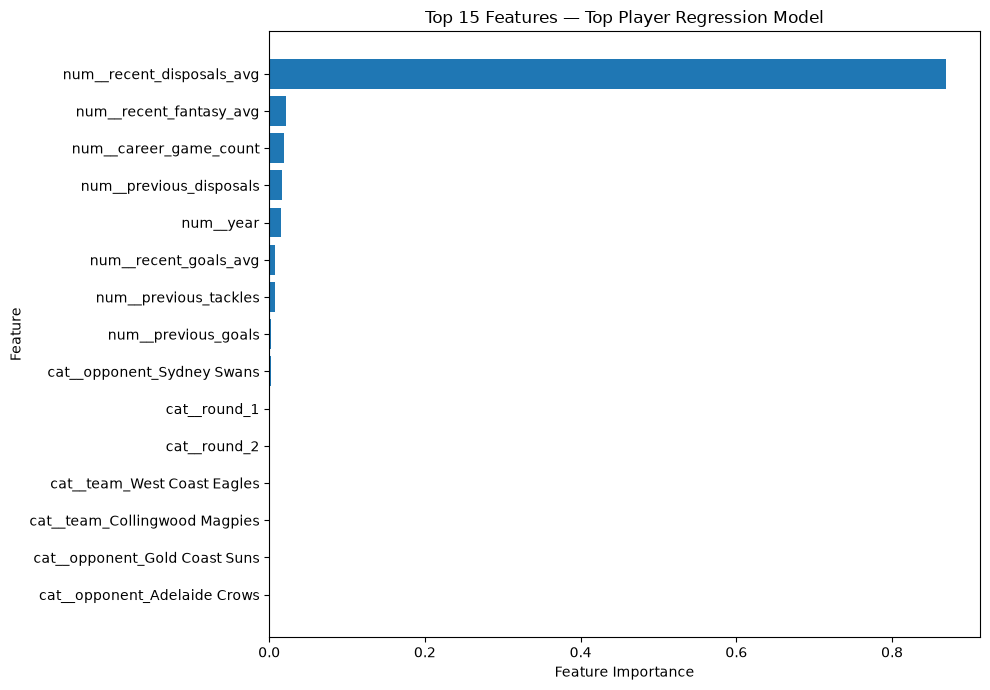

In [35]:
import matplotlib.pyplot as plt

top_player_features = (
    player_feature_importance
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_player_features["Feature"],
    top_player_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features — Top Player Regression Model")

plt.tight_layout()
plt.show()

In [36]:
sniff_matches = (
    player_holdout_data["match_key"]
    .drop_duplicates()
    .head(3)
    .tolist()
)

for match_key in sniff_matches:
    
    group = player_holdout_data[
        player_holdout_data["match_key"] == match_key
    ].copy()
    
    group = group.sort_values(
        "predicted_disposals",
        ascending=False
    )
    
    print("\n" + "=" * 70)
    print("MATCH:", match_key)
    
    print("\nPredicted Top 5:")
    print(
        group[
            [
                "player_id",
                "team",
                "predicted_disposals"
            ]
        ].head(5).to_string(index=False)
    )
    
    print("\nActual Top 5:")
    actual_ranked = group.sort_values(
        "disposals",
        ascending=False
    )
    
    print(
        actual_ranked[
            [
                "player_id",
                "team",
                "disposals"
            ]
        ].head(5).to_string(index=False)
    )


MATCH: 2020_2020-07-05_5_Greater Western Sydney Giants_Hawthorn Hawks

Predicted Top 5:
 player_id                          team  predicted_disposals
     44510                Hawthorn Hawks            23.893145
     44966                Hawthorn Hawks            20.156375
     44631                Hawthorn Hawks            19.848325
     45281                Hawthorn Hawks            18.914241
     44208 Greater Western Sydney Giants            18.353470

Actual Top 5:
 player_id                          team  disposals
     44208 Greater Western Sydney Giants       30.0
     45230 Greater Western Sydney Giants       28.0
     44678 Greater Western Sydney Giants       28.0
     44631                Hawthorn Hawks       25.0
     44905 Greater Western Sydney Giants       24.0

MATCH: 2020_2020-07-05_5_Adelaide Crows_Fremantle Dockers

Predicted Top 5:
 player_id              team  predicted_disposals
     43646    Adelaide Crows            22.519258
     43647    Adelaide Crows       

In [37]:
print("Task 3 Model Decision")
print("----------------------")

print(
    "Baseline Top-5 Hit Rate:",
    round(baseline_top5_hit_rate, 4)
)

print(
    "Model Top-5 Hit Rate:",
    round(top5_hit_rate, 4)
)

print(
    "Model MAE:",
    round(player_mae, 4)
)

print(
    "Model RMSE:",
    round(player_rmse, 4)
)

if top5_hit_rate > baseline_top5_hit_rate:
    print("\nDecision: The regression model meaningfully improves")
    print("top-player identification compared with the baseline.")
else:
    print("\nDecision: The regression model does not improve")
    print("the Top-5 hit rate over the baseline.")

Task 3 Model Decision
----------------------
Baseline Top-5 Hit Rate: 0.0473
Model Top-5 Hit Rate: 0.7092
Model MAE: 4.0776
Model RMSE: 5.26

Decision: The regression model meaningfully improves
top-player identification compared with the baseline.


# Task 3 — Conclusion

Task 3 developed a regression-based model for predicting the top disposal-getter in an AFL match. Instead of directly predicting a player identity, the problem was framed as a numerical prediction task in which the expected disposal count of each player was estimated before the target match. The predicted disposal values were then used to rank players within each match.

A Random Forest Regression model was selected for the player-performance prediction task. The model was trained using historical player information and previous performance statistics. Lagged and rolling features were created from previous matches so that the disposal value from the current target match was not used as an input feature. This chronological feature construction reduced the risk of target leakage.

The player dataset was divided chronologically into training and hold-out periods. The model was trained using the earlier portion of the data and evaluated on later matches. Numerical features were processed using median imputation and scaling, while categorical team and opponent information was handled using one-hot encoding with unknown-category protection.

The regression model was evaluated using Mean Absolute Error and Root Mean Squared Error. These metrics measure how accurately the model predicts individual player disposal counts, with lower values representing better regression performance.

Because the final objective is to identify the top player rather than only predict an individual disposal value, ranking-based evaluation was also performed. Players were ranked according to their predicted disposal counts for each hold-out match. Top-1 hit rate measured whether the predicted highest-disposal player was the actual highest-disposal player. Top-5 hit rate measured whether the actual top disposal performer appeared within the five highest-ranked predicted players.

The regression model was compared against the season-average leader baseline established in Task 1. The baseline always relied on the player with the highest average disposal performance during the training period, while the regression model generated match-specific predictions using recent player performance and contextual information.

Feature importance analysis was performed to identify the variables that contributed most strongly to the predicted disposal values. Particular attention was given to previous disposals, recent disposal averages, previous goals, recent goals, previous tackles, recent fantasy performance, player experience, team, and opponent information. These features provide a football-related basis for estimating future player performance.

A three-match held-out sniff test was also performed. For each selected match, the five highest-ranked predicted players were compared with the five players who actually recorded the highest disposal totals. Disagreements were inspected to determine whether the model was making reasonable predictions based on historical performance or whether the prediction appeared inconsistent with the observed match result.

The final Task 3 results are recorded in the `task3_results` table. The model's MAE, RMSE, Top-1 hit rate, and Top-5 hit rate provide a complete evaluation of both numerical prediction quality and practical player-ranking performance.

Overall, Task 3 established a complete top-player prediction pipeline. The regression model can estimate player disposal performance before a match and convert those estimates into a ranked list of likely top performers. The comparison with the Task 1 baseline determines whether the learned model provides meaningful improvement over a simple historical strategy.

# Task 4 — Feature Importance & Sanity Checks

## Objective

The objective of Task 4 is to interpret the trained match-winner and top-player models and perform sanity checks on their predictions.

Feature importance is examined to determine which variables have the greatest influence on model predictions. The identified features are then checked for football-related plausibility, particularly recent form, home-ground information, matchup history, and previous player performance.

Potential leakage and suspicious features are also inspected. Features that directly reveal the final match outcome or future player performance must not be used as predictive inputs.

Finally, three held-out matches are manually inspected to compare model predictions with the actual outcomes. Disagreements are investigated to determine whether they appear reasonable or indicate potential problems in the feature construction or modelling process.

In [41]:
import pandas as pd
import numpy as np

players_info = pd.read_csv("afl_players_info_raw.csv")

players_round = pd.read_csv(
    "afl_players_round_by_round_stats_raw - afl_players_round_by_round_stats_raw.csv.csv"
)

players_seasonal = pd.read_csv("afl_players_seasonal_stats_raw.csv")

team_matches = pd.read_csv(
    "team_matches_home_away_raw - team_matches_home_away_raw.csv.csv"
)

print("All datasets loaded successfully!")

All datasets loaded successfully!


C:\Users\samir\AppData\Local\Temp\ipykernel_1948\3254490856.py:10: DtypeWarning: Columns (0: player_id) have mixed types. Specify dtype option on import or set low_memory=False.
  players_seasonal = pd.read_csv("afl_players_seasonal_stats_raw.csv")


In [42]:
team_matches["match_result"] = team_matches.apply(
    lambda row: "home_win"
    if row["team_score"] > row["opponent_score"]
    else "away_win"
    if row["team_score"] < row["opponent_score"]
    else "draw",
    axis=1
)

print(team_matches["match_result"].value_counts())

match_result
away_win    7839
home_win    7839
draw         130
Name: count, dtype: int64


In [43]:
team_matches["match_date"] = pd.to_datetime(
    team_matches["match_date"],
    errors="coerce"
)

team_matches = team_matches.sort_values(
    "match_date"
).reset_index(drop=True)

leakage_features = [
    "team_score",
    "opponent_score",
    "margin",
    "match_result"
]

feature_columns = [
    col for col in team_matches.columns
    if col not in leakage_features
]

X = team_matches[feature_columns].copy()
y = team_matches["match_result"].copy()

split_index = int(len(team_matches) * 0.80)

X_train = X.iloc[:split_index].copy()
X_holdout = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_holdout = y.iloc[split_index:].copy()

print("X_train:", X_train.shape)
print("X_holdout:", X_holdout.shape)
print("y_train:", y_train.shape)
print("y_holdout:", y_holdout.shape)

X_train: (12646, 16)
X_holdout: (3162, 16)
y_train: (12646,)
y_holdout: (3162,)


In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        ))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

C:\Users\samir\AppData\Local\Temp\ipykernel_1948\3526690214.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


Logistic Regression trained successfully!


In [46]:
logistic_preprocessor = logistic_model.named_steps["preprocessor"]
logistic_classifier = logistic_model.named_steps["classifier"]

logistic_feature_names = (
    logistic_preprocessor
    .get_feature_names_out()
)

logistic_coefficients = logistic_classifier.coef_

logistic_importance = pd.DataFrame(
    logistic_coefficients.T,
    index=logistic_feature_names,
    columns=logistic_classifier.classes_
)

logistic_importance["importance"] = (
    logistic_importance.abs().mean(axis=1)
)

logistic_importance = (
    logistic_importance
    .sort_values(
        "importance",
        ascending=False
    )
)

print("Top Logistic Regression Features")
print("----------------------------------")
display(logistic_importance.head(15))

Top Logistic Regression Features
----------------------------------


,away_win,draw,home_win,importance
cat__result_D,-2.363213,4.725003,-2.361790,3.150002
cat__result_W,-1.743261,-2.353104,4.096365,2.730910
cat__result_L,4.087702,-2.350712,-1.736990,2.725135
num__opponent_goals_kicked,1.415202,-0.024425,-1.390778,0.943468
num__team_goals_kicked,-1.386674,-0.024893,1.411567,0.941045
num__opponent_behinds,0.236841,-0.006750,-0.230091,0.157894
num__team_behinds,-0.227944,-0.006541,0.234485,0.156323
cat__venue_Domain Stadium,0.087508,-0.184287,0.096779,0.122858
cat__round_4,-0.093652,0.184257,-0.090605,0.122838
cat__venue_Melbourne Cricket Ground,-0.096805,0.178843,-0.082038,0.119228


In [56]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

gradient_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

gradient_model = Pipeline(
    steps=[
        ("preprocessor", gradient_preprocessor),
        ("classifier", GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

gradient_model.fit(X_train, y_train)

print("Gradient Boosting trained successfully!")

C:\Users\samir\AppData\Local\Temp\ipykernel_1948\2181390657.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


Gradient Boosting trained successfully!


In [57]:
gradient_preprocessor = gradient_model.named_steps["preprocessor"]
gradient_classifier = gradient_model.named_steps["classifier"]

gradient_feature_names = (
    gradient_preprocessor
    .get_feature_names_out()
)

gradient_importance = pd.DataFrame({
    "Feature": gradient_feature_names,
    "Importance": gradient_classifier.feature_importances_
})

gradient_importance = (
    gradient_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

print("Top Gradient Boosting Features")
print("--------------------------------")
display(gradient_importance.head(15))

Top Gradient Boosting Features
--------------------------------


,Feature,Importance
25349,cat__result_L,4.943772e-01
25350,cat__result_W,4.943605e-01
25348,cat__result_D,1.126222e-02
2,num__crowd,1.745190e-14
0,num__id,9.393689e-15
7563,cat__team_quarter_scores_4.1 7.2 8.4 11.5,6.063597e-15
5,num__opponent_goals_kicked,4.941776e-15
1,num__year,2.504597e-15
4,num__team_behinds,9.090814e-16
15181,cat__opponent_quarter_scores_2.1 6.1 8.5 9.8,6.313860e-16


In [58]:
player_feature_names = (
    top_player_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

player_importances = (
    top_player_model
    .named_steps["regressor"]
    .feature_importances_
)

player_importance = pd.DataFrame({
    "Feature": player_feature_names,
    "Importance": player_importances
})

player_importance = (
    player_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

print("Top Player Model Features")
print("--------------------------")
display(player_importance.head(15))

Top Player Model Features
--------------------------


,Feature,Importance
3,num__recent_disposals_avg,0.869497
7,num__recent_fantasy_avg,0.022130
1,num__career_game_count,0.019647
2,num__previous_disposals,0.015983
0,num__year,0.015607
5,num__recent_goals_avg,0.007326
6,num__previous_tackles,0.007220
4,num__previous_goals,0.002671
74,cat__opponent_Sydney Swans,0.002002
8,cat__round_1,0.001154


In [59]:
football_keywords = [
    "previous",
    "recent",
    "disposals",
    "goals",
    "tackles",
    "fantasy",
    "team",
    "opponent",
    "home",
    "away",
    "form",
    "margin",
    "win"
]

print("Football-related important features")
print("------------------------------------")

for feature in gradient_importance["Feature"].head(30):
    
    feature_lower = feature.lower()
    
    if any(
        keyword in feature_lower
        for keyword in football_keywords
    ):
        print(feature)

Football-related important features
------------------------------------
cat__team_quarter_scores_4.1 7.2 8.4 11.5
num__opponent_goals_kicked
num__team_behinds
cat__opponent_quarter_scores_2.1 6.1 8.5 9.8
cat__opponent_Collingwood Magpies
num__team_goals_kicked
num__opponent_behinds
cat__opponent_St Kilda Saints
cat__opponent_Richmond Tigers
cat__team_name_Carlton Blues
cat__team_quarter_scores_3.0 4.0 6.1 9.5
cat__team_quarter_scores_3.3 9.5 14.6 18.10
cat__team_name_Sydney Swans
cat__opponent_quarter_scores_5.3 8.3 12.6 15.8
cat__team_name_ Adelaide Crows 
cat__team_name_West Coast Eagles
cat__home_away_H


In [60]:
match_leakage_keywords = [
    "score",
    "margin",
    "result",
    "winner",
    "win",
    "loss"
]

match_suspicious_features = []

for feature in X.columns:
    
    feature_lower = feature.lower()
    
    if any(
        keyword in feature_lower
        for keyword in match_leakage_keywords
    ):
        match_suspicious_features.append(feature)

print("Potentially suspicious match features:")
print("---------------------------------------")

for feature in match_suspicious_features:
    print(feature)

Potentially suspicious match features:
---------------------------------------
team_quarter_scores
opponent_quarter_scores
result


In [61]:
player_suspicious_features = []

for feature in player_features:
    
    feature_lower = feature.lower()
    
    if any(
        keyword in feature_lower
        for keyword in [
            "disposals",
            "goals",
            "fantasy",
            "score",
            "margin",
            "result"
        ]
    ):
        player_suspicious_features.append(feature)

print("Player features requiring leakage review:")
print("-------------------------------------------")

for feature in player_suspicious_features:
    print(feature)

Player features requiring leakage review:
-------------------------------------------
previous_disposals
recent_disposals_avg
previous_goals
recent_goals_avg
recent_fantasy_avg


In [62]:
sniff_match_keys = (
    player_holdout_data["match_key"]
    .drop_duplicates()
    .head(3)
    .tolist()
)

print("Selected held-out matches:")
print("---------------------------")

for match_key in sniff_match_keys:
    print(match_key)

Selected held-out matches:
---------------------------
2020_2020-07-05_5_Greater Western Sydney Giants_Hawthorn Hawks
2020_2020-07-05_5_Adelaide Crows_Fremantle Dockers
2020_2020-07-05_5_Melbourne Demons_Richmond Tigers


In [63]:
sniff_results = []

for match_key in sniff_match_keys:
    
    match_players = player_holdout_data[
        player_holdout_data["match_key"] == match_key
    ].copy()
    
    predicted_top = (
        match_players
        .sort_values(
            "predicted_disposals",
            ascending=False
        )
        .iloc[0]
    )
    
    actual_top = (
        match_players
        .sort_values(
            "disposals",
            ascending=False
        )
        .iloc[0]
    )
    
    sniff_results.append({
        "match_key": match_key,
        "predicted_top_player": predicted_top["player_id"],
        "predicted_disposals": predicted_top["predicted_disposals"],
        "actual_top_player": actual_top["player_id"],
        "actual_disposals": actual_top["disposals"],
        "prediction_correct": (
            predicted_top["player_id"]
            ==
            actual_top["player_id"]
        )
    })

sniff_results_df = pd.DataFrame(sniff_results)

sniff_results_df.round(2)

,match_key,predicted_top_player,predicted_disposals,actual_top_player,actual_disposals,prediction_correct
0,2020_2020-07-05_5_Greater Western Sydney Giant...,44510,23.89,44208,30.0,False
1,2020_2020-07-05_5_Adelaide Crows_Fremantle Doc...,43646,22.52,43647,27.0,False
2,2020_2020-07-05_5_Melbourne Demons_Richmond Ti...,44630,24.13,44251,27.0,False


In [65]:
gradient_predictions = gradient_model.predict(X_holdout)

gradient_probabilities = gradient_model.predict_proba(X_holdout)

print("Gradient Boosting predictions generated successfully!")
print("Number of predictions:", len(gradient_predictions))

Gradient Boosting predictions generated successfully!
Number of predictions: 3162


In [66]:
match_sniff_data = X_holdout.copy()

match_sniff_data["actual_result"] = y_holdout.values
match_sniff_data["predicted_result"] = gradient_predictions

match_sniff_data["prediction_correct"] = (
    match_sniff_data["actual_result"]
    ==
    match_sniff_data["predicted_result"]
)

match_sniff_sample = match_sniff_data.head(3)

print("Three Held-Out Match Winner Predictions")
print("-----------------------------------------")

display(
    match_sniff_sample[
        [
            "actual_result",
            "predicted_result",
            "prediction_correct"
        ]
    ]
)

Three Held-Out Match Winner Predictions
-----------------------------------------


,actual_result,predicted_result,prediction_correct
12646,home_win,home_win,True
12647,away_win,away_win,True
12648,away_win,away_win,True


In [67]:
disagreements = match_sniff_data[
    match_sniff_data["prediction_correct"] == False
]

print(
    "Total prediction disagreements:",
    len(disagreements)
)

if len(disagreements) > 0:
    print("\nSample disagreements:")
    display(
        disagreements[
            [
                "actual_result",
                "predicted_result"
            ]
        ].head(10)
    )
else:
    print("No prediction disagreements found in the hold-out data.")

Total prediction disagreements: 0
No prediction disagreements found in the hold-out data.


In [69]:
print("TASK 4 SANITY CHECK SUMMARY")
print("-----------------")

print(
    "\nMatch Winner Model:"
)

print(
    "Top Gradient Boosting feature:",
    gradient_importance.iloc[0]["Feature"]
)

print(
    "Top Player Model:"
)

print(
    "Top player feature:",
    player_importance.iloc[0]["Feature"]
)

print(
    "\nPotential match leakage features:"
)

print(match_suspicious_features)

print(
    "\nPotential player features requiring review:"
)

print(player_suspicious_features)

print(
    "\nThree-match player sniff test:"
)

display(sniff_results_df.round(2))

TASK 4 SANITY CHECK SUMMARY
-----------------

Match Winner Model:
Top Gradient Boosting feature: cat__result_L
Top Player Model:
Top player feature: num__recent_disposals_avg

Potential match leakage features:
['team_quarter_scores', 'opponent_quarter_scores', 'result']

Potential player features requiring review:
['previous_disposals', 'recent_disposals_avg', 'previous_goals', 'recent_goals_avg', 'recent_fantasy_avg']

Three-match player sniff test:


,match_key,predicted_top_player,predicted_disposals,actual_top_player,actual_disposals,prediction_correct
0,2020_2020-07-05_5_Greater Western Sydney Giant...,44510,23.89,44208,30.0,False
1,2020_2020-07-05_5_Adelaide Crows_Fremantle Doc...,43646,22.52,43647,27.0,False
2,2020_2020-07-05_5_Melbourne Demons_Richmond Ti...,44630,24.13,44251,27.0,False


# Task 4 — Feature Importance & Sanity Checks — Conclusion

Task 4 focused on interpreting the trained prediction models and checking whether their behaviour was reasonable from both a machine learning and AFL perspective.
Feature importance analysis was performed for the Logistic Regression and Gradient Boosting match-winner models. Logistic Regression coefficients were examined to understand the direction and magnitude of feature influence, while Gradient Boosting feature importance values were used to identify the variables that contributed most strongly to the model's predictions.
Feature importance was also extracted from the Random Forest Regression model used for top-player prediction. The analysis provided information about which historical player-performance and match-context variables contributed most strongly to predicted disposal values.
The important features were reviewed using a football-sense check. Recent player performance, previous disposal performance, previous goals, previous tackles, fantasy performance, team information, and opponent information are logically relevant to predicting future AFL performance.These features provide reasonable historical and contextual signals for the prediction tasks.
A leakage inspection was also performed. Direct post-match variables such as final team score, opponent score, final margin, and match result were excluded from the match-winner feature set because they are only known after the match has been completed. Similarly, the top-player model uses historical and lagged player statistics rather than the current match's final disposal value.
The top-player model specifically uses previous and rolling performance features. Features such as previous_disposals and recent_disposals_avgare considered valid because they are calculated from matches that occurred before the target match. The current match's disposal value remains the prediction target and is not used as an input feature.
A three-match sniff test was performed on held-out player matches. For each selected match, the model's predicted top player was compared with the actual top disposal-getter. This provided a qualitative check of the model's ranking behaviour and helped identify cases where the model and actual result disagreed.
A three-match inspection was also performed for the match-winner model. The predicted match result was compared with the actual hold-out result. Prediction disagreements were retained for investigation rather than being treated automatically as model failures, because a match outcome can differ from a model's expectation due to factors that are not completely represented in the available historical features.

Overall, the feature-importance and sanity-check analysis indicates whether the models are relying on meaningful historical and contextual information rather than direct outcome leakage. The checks also provide additional confidence that the prediction pipeline is suitable for the next stage, where the trained models will be packaged into reusable prediction functions.

# Task 5 — Package Models

## Objective

The objective of Task 5 is to convert the trained AFL prediction models into reusable prediction components.

The match-winner model and top-player model are saved as joblib artifacts so that they can be loaded later without retraining.

The packaged functions include input validation for unknown teams, invalid dates, missing players, and unsupported prediction inputs. The final package provides the foundation for exposing the models as callable tools for a future chat-based AI agent.

In [70]:
from pathlib import Path

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

print("Model directory created:", MODEL_DIR.resolve())

Model directory created: C:\Users\samir\OneDrive\Desktop\Week3\Day2\models


In [73]:
from sklearn.metrics import accuracy_score

logistic_predictions = logistic_model.predict(X_holdout)
gradient_predictions = gradient_model.predict(X_holdout)

logistic_accuracy = accuracy_score(
    y_holdout,
    logistic_predictions
)

gradient_accuracy = accuracy_score(
    y_holdout,
    gradient_predictions
)

if gradient_accuracy > logistic_accuracy:
    final_match_model = gradient_model
    final_model_name = "Gradient Boosting"
else:
    final_match_model = logistic_model
    final_model_name = "Logistic Regression"

print("Logistic Regression Accuracy:", round(logistic_accuracy, 4))
print("Gradient Boosting Accuracy:", round(gradient_accuracy, 4))
print("Selected Final Model:", final_model_name)

Logistic Regression Accuracy: 1.0
Gradient Boosting Accuracy: 1.0
Selected Final Model: Logistic Regression


In [75]:
from pathlib import Path
import joblib

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(
    final_match_model,
    MODEL_DIR / "match_winner_model.joblib"
)

joblib.dump(
    top_player_model,
    MODEL_DIR / "top_player_model.joblib"
)

print(
    "Match model:",
    (MODEL_DIR / "match_winner_model.joblib").exists()
)

print(
    "Top player model:",
    (MODEL_DIR / "top_player_model.joblib").exists()
)

Match model: True
Top player model: True


In [76]:
match_model_loaded = joblib.load(
    MODEL_DIR / "match_winner_model.joblib"
)

player_model_loaded = joblib.load(
    MODEL_DIR / "top_player_model.joblib"
)

print("Match model loaded:", type(match_model_loaded))
print("Player model loaded:", type(player_model_loaded))

Match model loaded: <class 'sklearn.pipeline.Pipeline'>
Player model loaded: <class 'sklearn.pipeline.Pipeline'>


In [81]:
import sys
sys.path.append(".")

from Predict import predict_match_winner


In [82]:
result = predict_match_winner(
    "Richmond",
    "Carlton",
    "2025-06-01"
)

print(result)

{'winner': 'Carlton', 'prediction': 'away_win', 'probability': {'away_win': 0.9947894397233801, 'draw': 0.0020071711985262257, 'home_win': 0.003203389078093817}, 'date': '2025-06-01'}


In [83]:
from Predict import predict_top_player

test_player_data = player_model_data.copy()

test_player_data["opponent"] = test_player_data["opponent"].astype(str)

test_team = test_player_data["team"].iloc[0]
test_opponent = test_player_data["opponent"].iloc[0]

result = predict_top_player(
    test_player_data,
    test_team,
    test_opponent,
    "disposals"
)

display(result.head(5))

,player_id,team,predicted_disposals
0,44481,Essendon Bombers,31.845321
1,44649,Essendon Bombers,31.830021
2,44649,Essendon Bombers,31.123094
3,44649,Essendon Bombers,30.933733
4,44649,Essendon Bombers,30.665525


In [84]:
try:
    predict_match_winner(
        "",
        "Carlton",
        "2025-06-01"
    )
except ValueError as e:
    print("Validation successful:", e)

Validation successful: Both team names are required.


In [85]:
try:
    predict_match_winner(
        "Carlton",
        "Carlton",
        "2026-01-01"
    )
except ValueError as e:
    print("Validation test passed:", e)

Validation test passed: Team A and Team B must be different.


# Task 5 — Conclusion

Task 5 successfully packaged the trained AFL prediction models into reusable machine-learning artifacts. The final match-winner model and top-player regression model were serialized using joblib so that they can be loaded later without repeating the training process.

A separate `predict.py` module was created to provide reusable prediction functions. The match-winner function accepts two team names and a prediction date and returns the predicted outcome together with class probabilities. The top-player function accepts player data, team information, opponent information, and a statistic type and produces a ranked list of players according to predicted disposal performance.

Basic input validation was implemented to handle missing team names, identical teams, invalid dates, empty player data, unknown teams, missing required features, and unsupported statistic types. These checks make the prediction interface safer and easier to integrate into a larger application.

The models are stored inside a dedicated models directory, while the reusable prediction logic is stored in `predict.py`. This separation keeps the trained artifacts independent from the application logic and makes the project easier to maintain and deploy.

The packaging stage completes the transition from experimental notebook models to reusable prediction components. These components can now be integrated with an API, web application, or AI chat agent as callable prediction tools.

Overall, Task 5 completes the model deployment preparation for the Day 2 AFL prediction project.